# Use external cell masks (skip Cellpose)

Cellpose inference is unnecessary when cell masks already exist (Cellpose remains an installation dependency). Its downstream functions accept a two-dimensional **label image**: background pixels are `0`, and every cell is identified by a positive integer (`1`, `2`, `3`, ...). The mask must have the same height, width and spatial alignment as the microscopy channels; matching dimensions alone do not establish alignment.

This short tutorial loads one of the image sets supplied with the repository, saves an illustrative labelled mask as NumPy `.npy`, loads it back through PARSHO's validated external-mask loader, and uses the loaded mask for nuclear and aggregate detection. No Cellpose model is imported or run.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import closing, disk

import tempfile
from parsho.img_utils import load_image, load_mask_npy
from parsho.examples import example_data_dir
from parsho import analyze_field, DetectionSettings
from parsho.colab_results import export_field_result
from parsho.segmentation import extract_masks

## Load one supplied image set

As in `parsho_aggregates_tutorial.ipynb`, the example data uses `C1-<name>` for nuclei, `C2-<name>` for aggregates, and `C3-<name>` for the cell channel. The path check lets the notebook run either from the repository root or from the `notebooks` directory.

In [2]:
DATA_DIR = example_data_dir()
SAMPLE_NAME = "E3_115plate4.tif"
MASK_DIR = Path(tempfile.mkdtemp(prefix="parsho_results_external_", dir=Path.cwd()))
MASK_PATH = MASK_DIR / "E3_115plate4_cell_masks.npy"

# Load the same raw channels as the aggregate tutorial, without controls
# or other prior information. No model is loaded or run.
cell_channel = load_image(DATA_DIR / f"C3-{SAMPLE_NAME}")
aggregate_channel = load_image(DATA_DIR / f"C2-{SAMPLE_NAME}")
nuclei_channel = load_image(DATA_DIR / f"C1-{SAMPLE_NAME}")
print(f"Loaded {SAMPLE_NAME} with shape {cell_channel.shape}")

Loaded E3_115plate4.tif with shape (2328, 2328)


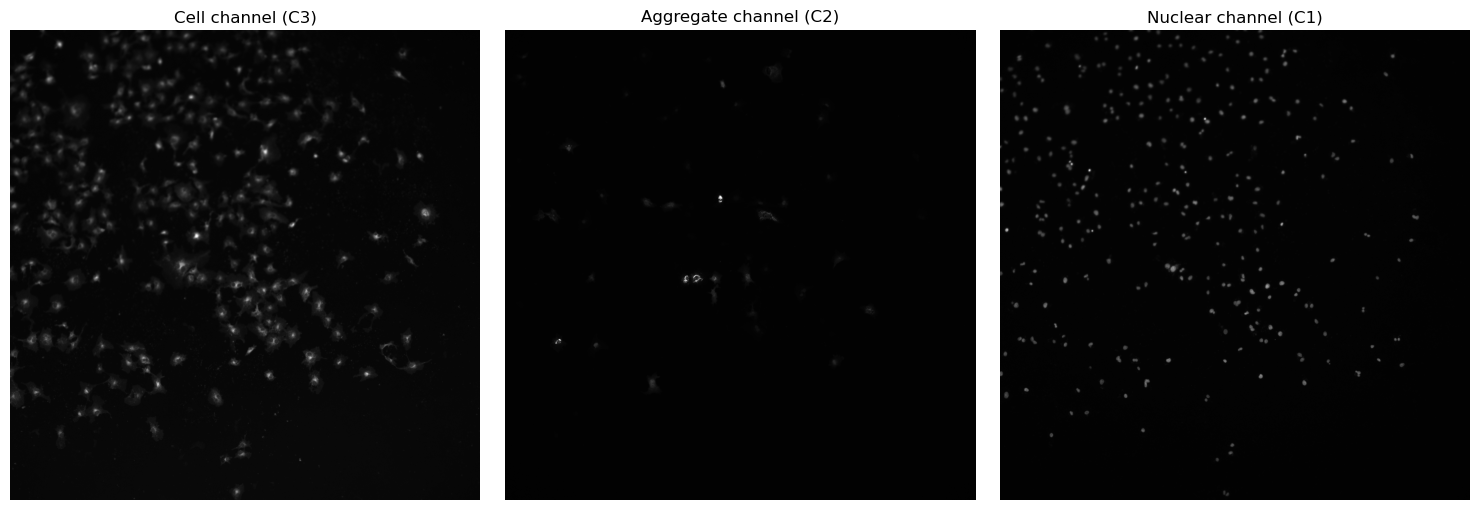

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, image, title in zip(
    axes,
    (cell_channel, aggregate_channel, nuclei_channel),
    ("Cell channel (C3)", "Aggregate channel (C2)", "Nuclear channel (C1)"),
):
    axis.imshow(image, cmap="gray")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()

## Save a labelled mask as `.npy`

The next cell creates a simple stand-in for a mask produced by another program, without relying on any precomputed masks. It thresholds the cell channel, fills enclosed regions, removes small regions, and assigns a separate integer label to each remaining region. It is not intended as a replacement for a dedicated cell-segmentation method.

For your usage, replace this cell with the label array exported by your segmentation software. If that software produces one binary mask per cell, combine those masks into one label image before saving.

In [4]:
cell_pixels = cell_channel > threshold_otsu(cell_channel)
cell_pixels = closing(cell_pixels, disk(2))
cell_pixels = ndi.binary_fill_holes(cell_pixels)

candidate_labels = label(cell_pixels)
region_sizes = np.bincount(candidate_labels.ravel())
large_enough = region_sizes >= 500
large_enough[0] = False  # Never retain the background label.
external_masks = label(large_enough[candidate_labels]).astype(np.int32)

MASK_DIR.mkdir(parents=True, exist_ok=True)
np.save(MASK_PATH, external_masks)
print(f"Saved {int(external_masks.max())} labelled regions to {MASK_PATH}")

Saved 238 labelled regions to /media/ograciac/light-roast/ograciac/MorroCells/parsho/notebooks/parsho_results_external_a4a92u85/E3_115plate4_cell_masks.npy


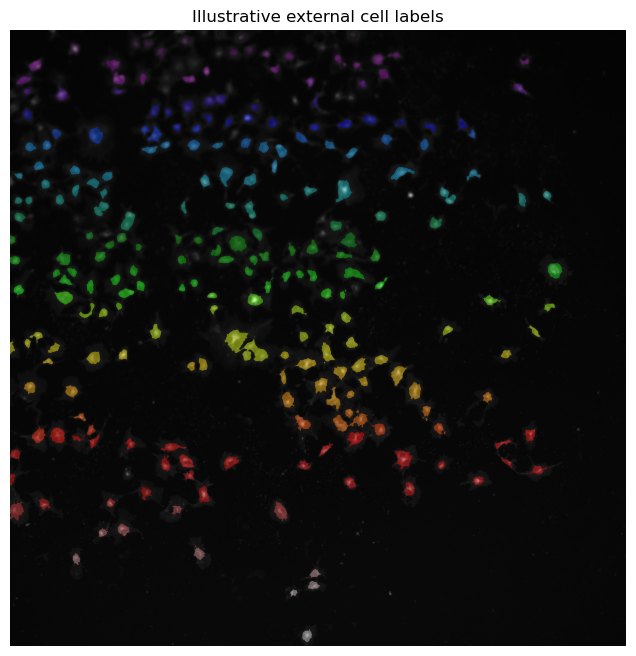

In [5]:
plt.figure(figsize=(8, 8))
plt.imshow(cell_channel, cmap="gray")
plt.imshow(
    np.ma.masked_equal(external_masks, 0),
    cmap="nipy_spectral",
    alpha=0.45,
)
plt.title("Illustrative external cell labels")
plt.axis("off")
plt.show()

## Load the external mask instead of running Cellpose

Set `MASK_PATH` to the `.npy` file supplied by the external segmentation workflow (CellProfiler, FIJI, etc). `kind="labels"` preserves cell identities, while `expected_shape` catches a size mismatch; inspect the overlay to confirm spatial alignment. The loader also rejects object arrays, negative labels, fractional labels, and arrays that are not two-dimensional after singleton axes are removed.

In [6]:
cell_masks = load_mask_npy(
    MASK_PATH,
    kind="labels",
    expected_shape=cell_channel.shape,
)

print(
    f"Reloaded {len(np.unique(cell_masks[cell_masks > 0]))} cell labels; "
    f"shape={cell_masks.shape}, dtype={cell_masks.dtype}"
)

Reloaded 238 cell labels; shape=(2328, 2328), dtype=int64


## Use the reloaded mask in PARSHO

From here onward, `cell_masks` replaces the array normally returned by `model.eval(...)`. The example below detects nuclear and aggregate pixels only inside the externally supplied cell regions. The same `cell_masks` array can be passed to PARSHO's filtering, morphology, overlay, and radial-distribution functions.

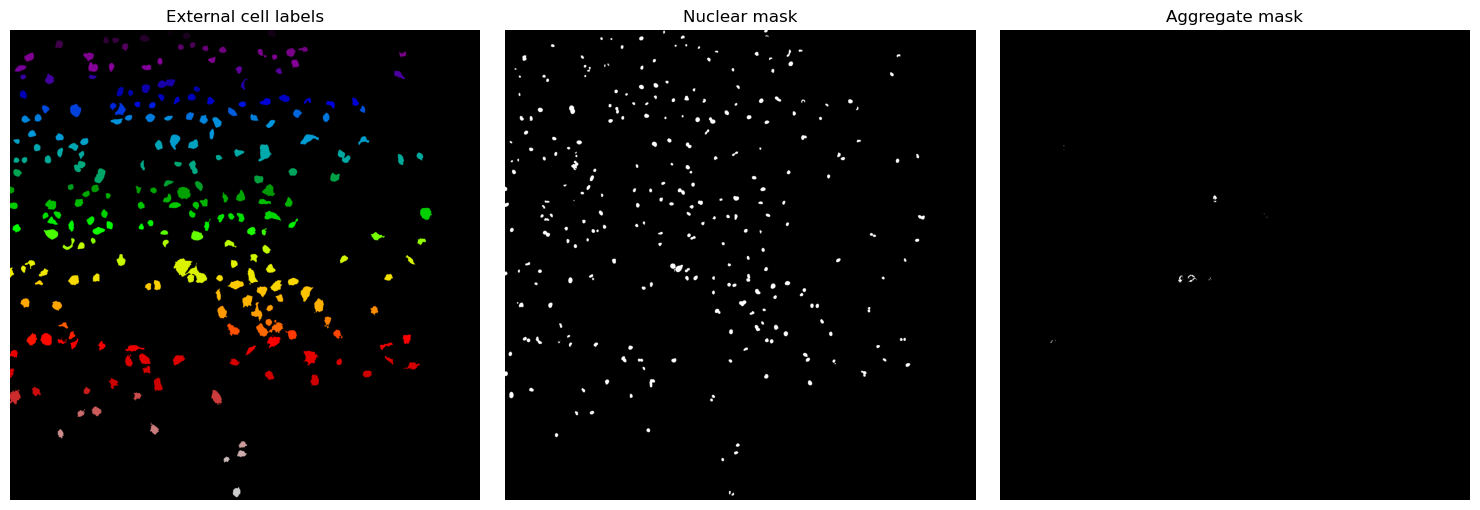

In [7]:
nuc_binary, nuc_labels, _ = extract_masks(
    aggregate_channel=nuclei_channel,
    cell_masks=cell_masks,
    method="otsu",
    min_size_px=5,
)
agg_binary, agg_labels, _ = extract_masks(
    aggregate_channel=aggregate_channel,
    cell_masks=cell_masks,
    method="otsu",
    min_size_px=2,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, mask, title in zip(
    axes,
    (cell_masks, nuc_binary, agg_binary),
    ("External cell labels", "Nuclear mask", "Aggregate mask"),
):
    axis.imshow(mask, cmap="nipy_spectral" if title.startswith("External") else "gray")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()

## Adapting this to your data

1. Export a single 2-D labelled mask from the external segmentation tool.
2. Save it with `np.save("cell_masks.npy", labelled_mask)`.
3. Load the matching microscopy channels with `load_field_channels(...)`.
4. Load and validate the labels with `load_mask_npy(..., kind="labels", expected_shape=image.shape)`.
5. Use the returned array as `cell_masks` everywhere the other tutorials use Cellpose output.

Do not use `kind="binary"` for multi-cell analysis: it merges all nonzero pixels into a Boolean foreground and discards individual cell identities.

## Optional: export the same measurements as Colab

The reloaded masks can go directly into the shared analysis, with or without nuclei. This example uses the supplied nuclear image but does not exclude nuclear pixels or require any signal to retain cells. All original cell labels are retained.

The illustrative threshold-based cell masks are **not validated biological segmentations**. Replace them before drawing conclusions. All results are saved in the printed local folder; use [Colab](https://colab.research.google.com/github/Fraternalilab/PARSHO/blob/main/notebooks/PARSHO_Colab.ipynb) for guided Cellpose segmentation and browser downloads.

In [8]:
signals = {"aggregates": aggregate_channel}
result = analyze_field(
    cell_masks, signals,
    detection={"aggregates": DetectionSettings(method="otsu", min_size=2)},
    nucleus=nuclei_channel, remove_nuclear=False,
    radial=True, radial_center="auto",
)
RESULTS_DIR = export_field_result(
    MASK_DIR / "results", result, signals,
    settings={"data_directory": str(DATA_DIR), "sample": SAMPLE_NAME, "external_mask": str(MASK_PATH),
              "illustrative_masks_only": True},
    nucleus=nuclei_channel, save_all_radial=False,
)
print(f"Tables, arrays, overlays and measurement definitions: {RESULTS_DIR}")

Tables, arrays, overlays and measurement definitions: /media/ograciac/light-roast/ograciac/MorroCells/parsho/notebooks/parsho_results_external_a4a92u85/results
